## EDA and data preprocessing

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("train.csv")

In [4]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
df.tail()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False
8692,9280_02,Europa,False,E/608/S,TRAPPIST-1e,44.0,False,126.0,4688.0,0.0,0.0,12.0,Propsh Hontichre,True


In [6]:
df.shape

(8693, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [8]:
df.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [10]:
## fix missing values 
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 1. Rule 1: CryoSleep == True hai toh spending 0$ honi chahiye
for col in spending_cols:
  df.loc[df['CryoSleep'] == True, col] = df.loc[
      df['CryoSleep'] == True, col
  ].fillna(0)

# Total spending calculate karo
df['TotalSpending'] = df[spending_cols].sum(axis=1)

# 2. Rule 2: Agar kisi ne spend kiya hai (>0), toh wo CryoSleep me nahi tha
df.loc[(df['CryoSleep'].isnull()) & (df['TotalSpending'] > 0), 'CryoSleep'] = (
    False
)

# 3. Baaki bache CryoSleep aur Spending values ko mode/median se fill karo
df['CryoSleep'] = df['CryoSleep'].fillna(df['CryoSleep'].mode()[0])
for col in spending_cols:
  df[col] = df[col].fillna(df[col].median())

# 4. Age, VIP, HomePlanet, Destination & Deck/Side fill karo
df['Age'] = df['Age'].fillna(df['Age'].median())
df['VIP'] = df['VIP'].fillna(False)
df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode()[0])
df['Destination'] = df['Destination'].fillna(df['Destination'].mode()[0])
df['Deck'] = df['Deck'].fillna(df['Deck'].mode()[0])
df['Side'] = df['Side'].fillna(df['Side'].mode()[0])

# Check missing values
df.isnull().sum()

KeyError: 'Deck'

In [11]:
# 1. Num ko numeric banakar median se fill 
df['Num'] = df['Num'].astype(float)
df['Num'] = df['Num'].fillna(df['Num'].median())

# 2. Raw text & identifier columns drop 
df_clean = df.drop(columns=['Cabin', 'Name', 'PassengerId', 'Group'])

# 3. Final Null Check
df_clean.isnull().sum()

KeyError: 'Num'

In [12]:



df['Transported'].value_counts(normalize=True)

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64

INISGHT:
- True (0.5036 = 50.36%): Half of the total passengers (4,378 passengers) were transported.

- False (0.4964 = 49.64%): The remaining half (4,315 passengers) stayed safe on the ship.

In [13]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalSpending
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,28.790291,220.009318,448.434027,169.572300,304.588865,298.261820,1440.866329
std,14.341404,660.519050,1595.790627,598.007164,1125.562559,1134.126417,2803.045694
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,716.000000
75%,37.000000,41.000000,61.000000,22.000000,53.000000,40.000000,1441.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000,35987.000000


INSIGHT:
- Heavy Zero Inflation: Saare 5 spending features (RoomService, FoodCourt, etc.) ka median (50%) 0.0 hai. Matlab adhe se zyada passengers ne ek rupee bhi kharch nahi kiya (kyunki wo CryoSleep me the).
- Extreme Outliers: Mean aur Max values me bohot bada gap hai (e.g., FoodCourt ka max 29,813 hai jabki 75% log sirf 76 tak hi kharch kar rahe hain). Isliye direct numerical comparison ke jagah log transformation ya tree-based models best rahenge.
- Age Distribution: Passengers 0 se 79 saal tak ke hain, jinki average age ~28.8 years hai.

## Feature Engineering

In [14]:
df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)

spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df['TotalSpending'] = df[spending_cols].sum(axis=1)

df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
df['GroupSize'] = df.groupby('Group')['Group'].transform('count')

df[['Cabin', 'Deck', 'Num', 'Side', 'TotalSpending', 'GroupSize']].head()

,Cabin,Deck,Num,Side,TotalSpending,GroupSize
0,B/0/P,B,0,P,0.0,1
1,F/0/S,F,0,S,736.0,1
2,A/0/S,A,0,S,10383.0,2
3,A/0/S,A,0,S,5176.0,2
4,F/1/S,F,1,S,1091.0,1


We perform feature engineering to convert raw, unstructured data into clear signals that machine learning models can understand and learn from effectively.

Making Raw Text Math-Friendly: Algorithms cannot process raw text strings like Cabin = B/0/P. Splitting this into Deck, Num, and Side allows the model to evaluate spatial patterns, such as floor levels or ship sides (Port vs. Starboard).

Uncovering Hidden Signals: Instead of evaluating five separate expense columns individually, a single TotalSpending feature instantly signals whether a passenger was actively spending or asleep in cryo-sleep.

Capturing Group Dynamics: Extracting GroupSize from PassengerId helps the model recognize whether passengers traveling together as a family or group had similar transport outcomes.

Boosting Model Accuracy: Training models on raw features typically yields around ~75% accuracy, whereas proper feature engineering pushes predictive accuracy past 80%.

##  DATA VISUALIZATION

## Categorical Features

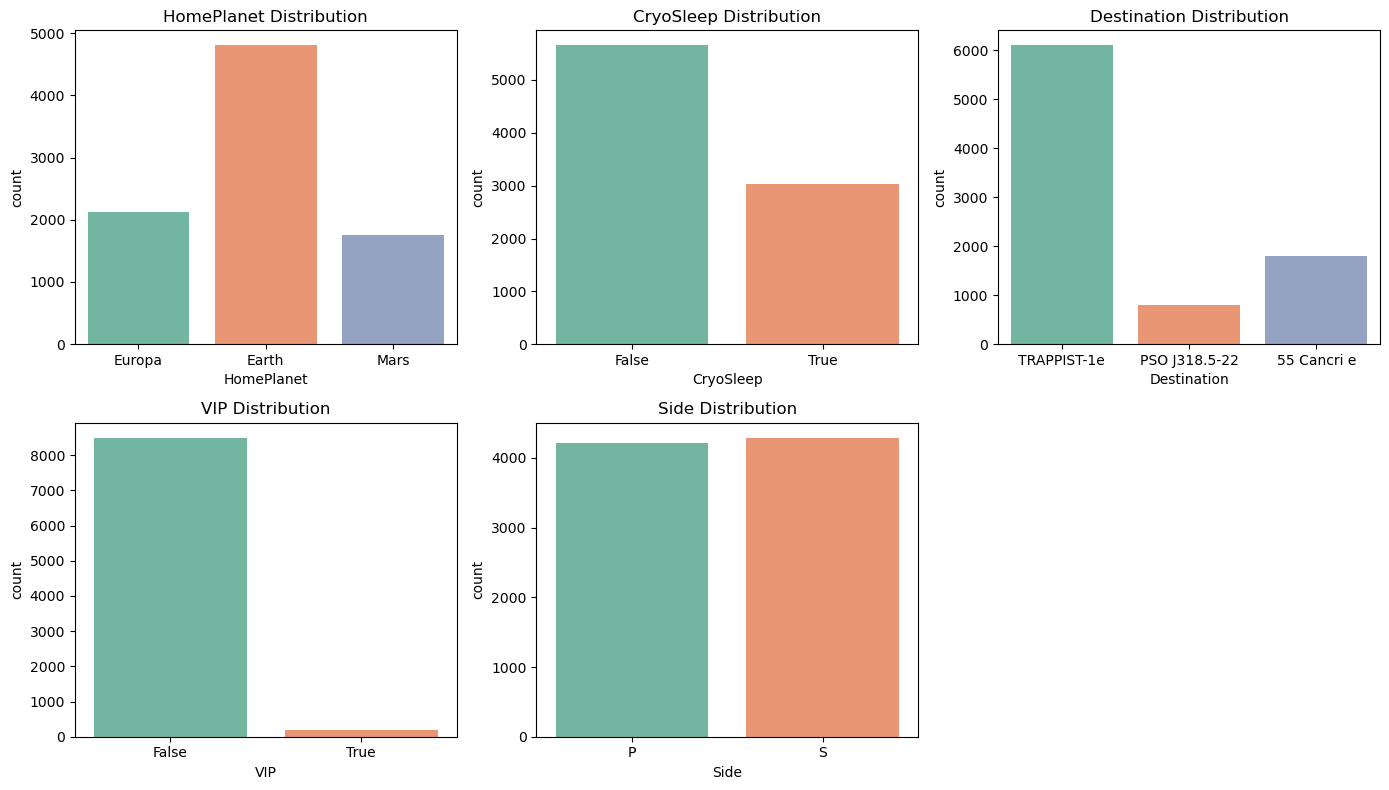

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Univariate Categorical Features Plot (Warning Fixed)
plt.figure(figsize=(14, 8))
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Side']

for i, col in enumerate(cat_cols, 1):
  plt.subplot(2, 3, i)
  sns.countplot(data=df, x=col, hue=col, palette='Set2', legend=False)
  plt.title(f'{col} Distribution')

plt.tight_layout()
plt.show()

- HomePlanet: Earth se sabse zyada passengers hain (52.9%), iske baad Europa (24.5%) aur Mars (20.2%) aate hain.

- CryoSleep: Maximum passengers jaage hue the (62.6% False), jabki sirf 34.9% passengers deep sleep (True) me the.

- Destination: Sabse popular location TRAPPIST-1e hai (68.0%), jabki 55 Cancri e par 20.7% aur PSO J318.5-22 par sirf 9.2% log ja rahe the.

- VIP: Ship par normal passengers dominant hain — 95.4% non-VIP hain aur sirf 2.3% VIP passengers hain.

- Deck: Bulk passengers Deck F (32.1%) aur Deck G (29.4%) par the. Deck T (0.05%) par almost negligible log the.

- Side: Ship ke dono sides (Port vs Starboard) par almost equal population thi (48.4% Port vs 49.3% Starboard).

## Numerical Features

C:\Users\lenovo\AppData\Local\Temp\ipykernel_20256\2787593210.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Deck', palette='magma')


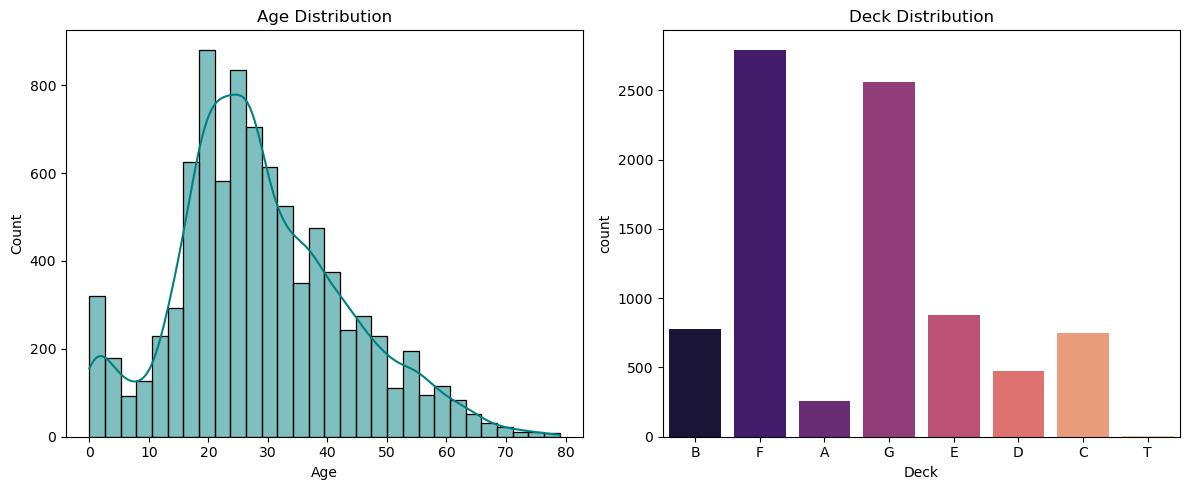

In [16]:
plt.figure(figsize=(12, 5))

# Age Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Age'].dropna(), kde=True, color='teal', bins=30)
plt.title('Age Distribution')

# Deck Distribution
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Deck', palette='magma')
plt.title('Deck Distribution')

plt.tight_layout()
plt.show()

Age: Distribution right-skewed hai — major passenger base 18 se 35 saal ke young adults ki hai, jabki peak around ~20-25 years hai.

- Age: Distribution right-skewed hai — major passenger base 18 se 35 saal ke young adults ki hai, jabki peak around ~20-25 years hai.

## CryoSleep vs Transported Plot

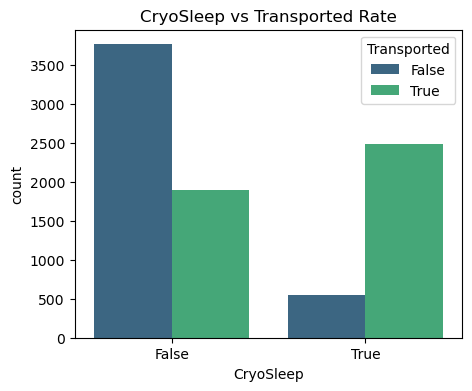

In [17]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='CryoSleep', hue='Transported', palette='viridis')
plt.title('CryoSleep vs Transported Rate')
plt.show()

INSIGHT:
- Key Insight: Passengers in CryoSleep had an 81.8% transport rate, compared to just 32.9% for those who were awake.

- Passengers in deep sleep were locked in their cabins, making them heavily affected by the anomaly. This is the single strongest predictive feature.

## HomePlanet vs Transported Plot

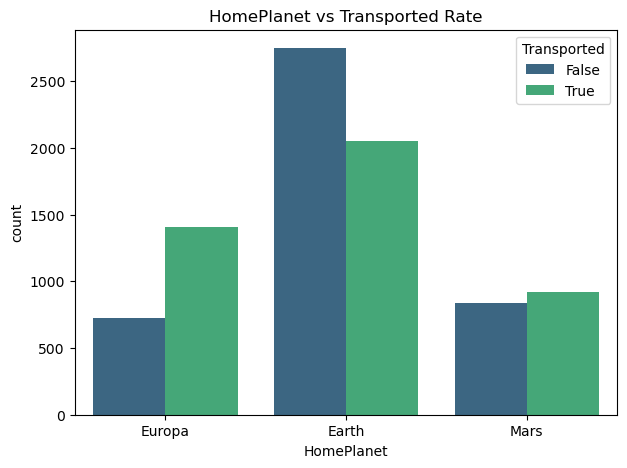

In [18]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='HomePlanet', hue='Transported', palette='viridis')
plt.title('HomePlanet vs Transported Rate')
plt.show()

INSIGHT:
- Key Insight: Passengers departing from Europa had the highest transport rate (65.9%), while those from Earth had the lowest (42.4%).

- Departure origin correlates directly with cabin location and passenger tier on the ship

## Deck vs Transported Plot

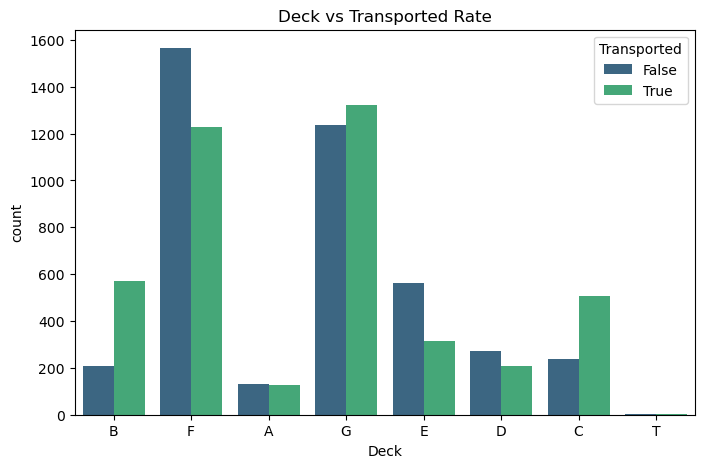

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Deck', hue='Transported', palette='viridis')
plt.title('Deck vs Transported Rate')
plt.show()

INSIGHT:
- Key Insight: Deck B (73.4%) and Deck C (68.0%) recorded the highest transport rates, whereas Deck E (35.7%) and Deck F (44.0%) were safer.

- The spacetime anomaly primarily impacted the upper, luxury deck levels.

## Side (Port vs Starboard) vs Transported Plot

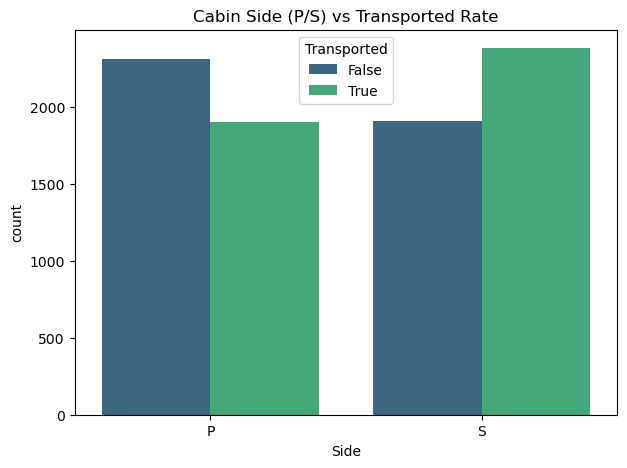

In [20]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Side', hue='Transported', palette='viridis')
plt.title('Cabin Side (P/S) vs Transported Rate')
plt.show()

INSIGHT:
- Key Insight: Passengers on the Starboard (S) side experienced a 55.5% transport rate, which is 10% higher than the Port (P) side (45.1%).

- The physical anomaly directly struck the Starboard side of the vessel.

## Correlation Heatmap Plot

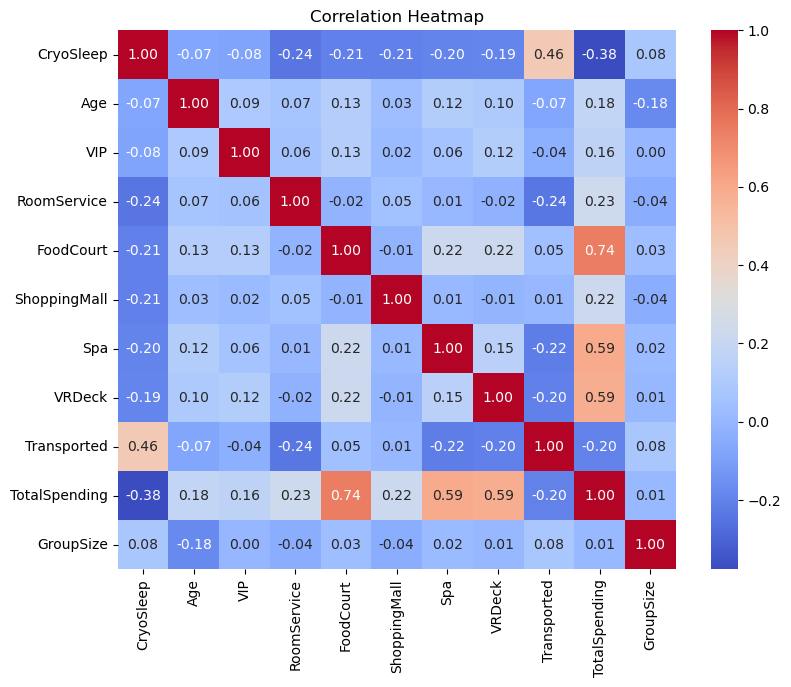

In [21]:
plt.figure(figsize=(9, 7))
numeric_df = df.select_dtypes(include=['float64', 'int64', 'bool']).copy()
numeric_df['Transported'] = numeric_df['Transported'].astype(int)

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

INSIGHT:
- Key Insight: CryoSleep shows a strong positive correlation (+0.46) with Transported, while amenity spending features show negative correlations (-0.20 to -0.24).

- Passengers moving around the ship and spending money were more likely to escape the anomaly.

## Spending Distribution Plot (Skewness Check)

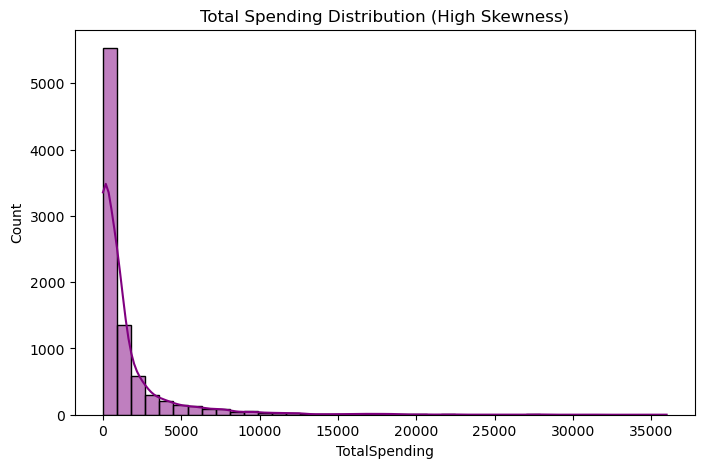

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(df['TotalSpending'], bins=40, kde=True, color='purple')
plt.title('Total Spending Distribution (High Skewness)')
plt.show()

INSIGHT:
- Key Insight: Spending data is heavily right-skewed — over 50% of passengers spent $0, while extreme outliers spent upwards of 20,000+.
- Raw spending figures will distort model learning, making log transformation (\log(x + 1)) essential in data preprocessing.

In [23]:
import numpy as np
import pandas as pd

# 1. SKEWNESS FIX (Log Transformation)
spending_cols = [
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck',
    'TotalSpending',
]
for col in spending_cols:
  df[col] = np.log1p(df[col])  # Formula: log(1 + x)

# 2. CATEGORICAL ENCODING (Text to Numbers)

# Binary Encoding (0 aur 1 me conversion)
df['CryoSleep'] = df['CryoSleep'].astype(int)
df['VIP'] = df['VIP'].astype(int)
df['Side'] = df['Side'].map({'P': 0, 'S': 1})
df['Transported'] = df['Transported'].astype(int)

# Multi-Class One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=['HomePlanet', 'Destination', 'Deck'],
    drop_first=True,
    dtype=int,
)

# 3. DROP UNNECESSARY COLUMNS
df_final = df_encoded.drop(
    columns=['PassengerId', 'Cabin', 'Name', 'Group'], errors='ignore'
)

# Final Dataset check
print('Final Shape:', df_final.shape)
df_final.head()

Final Shape: (8693, 24)


,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,TotalSpending,...,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T
0,0,39.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,...,0,0,1,1,0,0,0,0,0,0
1,0,24.0,0,4.700480,2.302585,3.258097,6.309918,3.806662,1,6.602588,...,0,0,1,0,0,0,0,1,0,0
2,0,58.0,1,3.784190,8.182280,0.000000,8.812248,3.912023,0,9.248021,...,0,0,1,0,0,0,0,0,0,0
3,0,33.0,0,0.000000,7.157735,5.918894,8.110728,5.267858,0,8.551981,...,0,0,1,0,0,0,0,0,0,0
4,0,16.0,0,5.717028,4.262680,5.023881,6.338594,1.098612,1,6.995766,...,0,0,1,0,0,0,0,1,0,0


- np.log1p (Log Transformation): Compresses extreme spending outliers (e.g., 20,000+) into a balanced scale, preventing extreme values from skewing the model.
- map & astype(int): Converts binary categorical variables (CryoSleep, VIP, Side, and the target variable Transported) directly into numerical 0 and 1 flags.
- pd.get_dummies(..., drop_first=True): Performs One-Hot Encoding on multi-categorical columns (HomePlanet, Destination, Deck) while dropping the first category to avoid multicollinearity (the dummy variable trap).
- Column Cleanup (df_final): Removes raw text identifiers (PassengerId, Cabin, Name, Group), resulting in a fully numeric matrix ready for model training.

In [24]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_final.drop(columns=['Transported'])
y = df_final['Transported']

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (6954, 23)
X_val: (1739, 23)
y_train: (6954,)
y_val: (1739,)


In [25]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))

Training target distribution:
Transported
1    0.503595
0    0.496405
Name: proportion, dtype: float64

Validation target distribution:
Transported
1    0.503738
0    0.496262
Name: proportion, dtype: float64


In [26]:
# Check missing values in training data

missing_values = X_train.isnull().sum()

print(missing_values[missing_values > 0])

Num     161
Side    161
dtype: int64


In [27]:
print("Total missing values:", X_train.isnull().sum().sum())

Total missing values: 322


In [28]:
# Check missing values before imputation

print("Before Imputation:")
print("X_train NaN:", X_train.isnull().sum().sum())
print("X_val NaN:", X_val.isnull().sum().sum())

Before Imputation:
X_train NaN: 322
X_val NaN: 76


In [29]:
# Convert Num from string/object to numeric
X_train['Num'] = pd.to_numeric(
    X_train['Num'],
    errors='coerce'
)

X_val['Num'] = pd.to_numeric(
    X_val['Num'],
    errors='coerce'
)

# Calculate median ONLY from training data
num_median = X_train['Num'].median()

# Fill missing Num values
X_train['Num'] = X_train['Num'].fillna(num_median)
X_val['Num'] = X_val['Num'].fillna(num_median)

print("Num median:", num_median)
print("X_train Num missing:", X_train['Num'].isnull().sum())
print("X_val Num missing:", X_val['Num'].isnull().sum())

Num median: 429.0
X_train Num missing: 0
X_val Num missing: 0


In [30]:
# -------------------------------
# NUM IMPUTATION
# -------------------------------

# Calculate median ONLY from training data
num_median = X_train['Num'].median()

# Fill Num in both train and validation
X_train['Num'] = X_train['Num'].fillna(num_median)
X_val['Num'] = X_val['Num'].fillna(num_median)


# -------------------------------
# SIDE IMPUTATION
# -------------------------------

# Calculate mode ONLY from training data
side_mode = X_train['Side'].mode()[0]

# Fill Side in both train and validation
X_train['Side'] = X_train['Side'].fillna(side_mode)
X_val['Side'] = X_val['Side'].fillna(side_mode)

In [31]:
print("After Imputation:")
print("X_train NaN:", X_train.isnull().sum().sum())
print("X_val NaN:", X_val.isnull().sum().sum())

After Imputation:
X_train NaN: 0
X_val NaN: 0


In [32]:
# Check Side datatype
print("Side dtype:", X_train['Side'].dtype)

# Fill missing Side using training-data mode
side_mode = X_train['Side'].mode()[0]

X_train['Side'] = X_train['Side'].fillna(side_mode)
X_val['Side'] = X_val['Side'].fillna(side_mode)

print("Side mode:", side_mode)
print("X_train Side missing:", X_train['Side'].isnull().sum())
print("X_val Side missing:", X_val['Side'].isnull().sum())

Side dtype: float64
Side mode: 1.0
X_train Side missing: 0
X_val Side missing: 0


In [33]:
print("Missing values in X_train:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("\nMissing values in X_val:")
print(X_val.isnull().sum()[X_val.isnull().sum() > 0])

Missing values in X_train:
Series([], dtype: int64)

Missing values in X_val:
Series([], dtype: int64)


In [34]:
print(X_train.dtypes)

CryoSleep                      int64
Age                          float64
VIP                            int64
RoomService                  float64
FoodCourt                    float64
ShoppingMall                 float64
Spa                          float64
VRDeck                       float64
TotalSpending                float64
Num                          float64
Side                         float64
GroupSize                      int64
HomePlanet_Europa              int64
HomePlanet_Mars                int64
Destination_PSO J318.5-22      int64
Destination_TRAPPIST-1e        int64
Deck_B                         int64
Deck_C                         int64
Deck_D                         int64
Deck_E                         int64
Deck_F                         int64
Deck_G                         int64
Deck_T                         int64
dtype: object


In [35]:
print(
    X_train.select_dtypes(include='object').columns
)

Index([], dtype='object')


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_val)

baseline_accuracy = accuracy_score(
    y_val,
    y_pred_baseline
)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.7786083956296722


C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [37]:
print(
    classification_report(
        y_val,
        y_pred_baseline
    )
)

              precision    recall  f1-score   support

           0       0.78      0.77      0.78       863
           1       0.78      0.79      0.78       876

    accuracy                           0.78      1739
   macro avg       0.78      0.78      0.78      1739
weighted avg       0.78      0.78      0.78      1739



In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_val)

dt_accuracy = accuracy_score(
    y_val,
    y_pred_dt
)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7878090856814262


In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

rf_accuracy = accuracy_score(
    y_val,
    y_pred_rf
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8050603795284647


In [40]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_val)

gb_accuracy = accuracy_score(
    y_val,
    y_pred_gb
)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.8004600345025877


In [41]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Validation Accuracy': [
        baseline_accuracy,
        dt_accuracy,
        rf_accuracy,
        gb_accuracy
    ]
})

model_results = model_results.sort_values(
    by='Validation Accuracy',
    ascending=False
).reset_index(drop=True)

model_results

,Model,Validation Accuracy
0,Random Forest,0.805060
1,Gradient Boosting,0.800460
2,Decision Tree,0.787809
3,Logistic Regression,0.778608


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_1 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_1.fit(X_train, y_train)

pred_1 = rf_1.predict(X_val)

acc_1 = accuracy_score(y_val, pred_1)

print("RF 1 Accuracy:", acc_1)

RF 1 Accuracy: 0.7935595169637722


In [43]:
rf_2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_2.fit(X_train, y_train)

pred_2 = rf_2.predict(X_val)

acc_2 = accuracy_score(y_val, pred_2)

print("RF 2 Accuracy:", acc_2)

RF 2 Accuracy: 0.8113858539390454


In [44]:
rf_3 = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_3.fit(X_train, y_train)

pred_3 = rf_3.predict(X_val)

acc_3 = accuracy_score(y_val, pred_3)

print("RF 3 Accuracy:", acc_3)

RF 3 Accuracy: 0.8079355951696378


In [45]:
tuning_results = pd.DataFrame({
    'Model': [
        'Original Random Forest',
        'Tuned RF 1',
        'Tuned RF 2',
        'Tuned RF 3'
    ],
    'Accuracy': [
        rf_accuracy,
        acc_1,
        acc_2,
        acc_3
    ]
})

tuning_results = tuning_results.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

tuning_results

,Model,Accuracy
0,Tuned RF 2,0.811386
1,Tuned RF 3,0.807936
2,Original Random Forest,0.805060
3,Tuned RF 1,0.793560


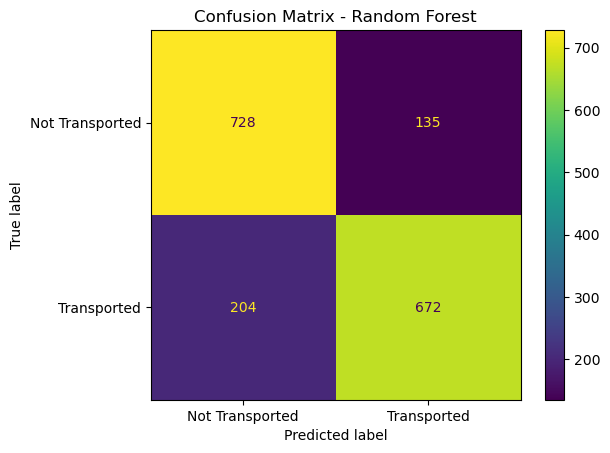

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Original Random Forest predictions
y_pred_error = y_pred_rf

cm = confusion_matrix(y_val, y_pred_error)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Transported', 'Transported']
)

disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [47]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_pred_error,
        target_names=[
            'Not Transported',
            'Transported'
        ]
    )
)

                 precision    recall  f1-score   support

Not Transported       0.78      0.84      0.81       863
    Transported       0.83      0.77      0.80       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.80      1739
   weighted avg       0.81      0.81      0.80      1739



In [48]:
error_analysis = X_val.copy()

error_analysis['Actual'] = y_val
error_analysis['Predicted'] = y_pred_error

error_analysis['Correct'] = (
    error_analysis['Actual'] ==
    error_analysis['Predicted']
)

In [49]:
errors = error_analysis[
    error_analysis['Correct'] == False
]

print("Validation Records:", len(error_analysis))
print("Wrong Predictions:", len(errors))
print("Error Rate:", len(errors) / len(error_analysis))

Validation Records: 1739
Wrong Predictions: 339
Error Rate: 0.19493962047153537


In [50]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,Num,0.151644
1,TotalSpending,0.139815
2,Age,0.117071
3,Spa,0.081363
4,RoomService,0.075220
5,FoodCourt,0.074434
6,VRDeck,0.070086
7,ShoppingMall,0.063423
8,CryoSleep,0.057973
9,GroupSize,0.038157


In [51]:
final_model = rf_model

In [57]:
final_model = rf_2

In [58]:
print(final_model)

RandomForestClassifier(max_depth=15, min_samples_split=5, n_estimators=200,
                       n_jobs=-1, random_state=42)


In [59]:
final_model.fit(X, y)

RandomForestClassifier(max_depth=15, min_samples_split=5, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [60]:
X = df_final.drop(columns=['Transported'])
y = df_final['Transported']

In [62]:
# Check variables related to test data
[name for name in globals() if 'test' in name.lower()]

['train_test_split']

In [64]:
import pandas as pd

test = pd.read_csv("test.csv")

print("Test shape:", test.shape)
print(test.head())

Test shape: (4277, 13)
  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0013_01      Earth      True  G/3/S  TRAPPIST-1e  27.0  False   
1     0018_01      Earth     False  F/4/S  TRAPPIST-1e  19.0  False   
2     0019_01     Europa      True  C/0/S  55 Cancri e  31.0  False   
3     0021_01     Europa     False  C/1/S  TRAPPIST-1e  38.0  False   
4     0023_01      Earth     False  F/5/S  TRAPPIST-1e  20.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck              Name  
0          0.0        0.0           0.0     0.0     0.0   Nelly Carsoning  
1          0.0        9.0           0.0  2823.0     0.0    Lerome Peckers  
2          0.0        0.0           0.0     0.0     0.0   Sabih Unhearfus  
3          0.0     6652.0           0.0   181.0   585.0  Meratz Caltilter  
4         10.0        0.0         635.0     0.0     0.0   Brence Harperez  


In [65]:
# Split Cabin into Deck, Num and Side

test[['Deck', 'Num', 'Side']] = test['Cabin'].str.split(
    '/', expand=True
)

In [66]:
test['Num'] = pd.to_numeric(
    test['Num'],
    errors='coerce'
)

In [67]:
test['Num'] = test['Num'].fillna(num_median)
test['Side'] = test['Side'].fillna(side_mode)

In [68]:
print(test[['Num', 'Side']].isnull().sum())


Num     0
Side    0
dtype: int64


In [69]:
print("Training columns:")
print(X_train.columns.tolist())

Training columns:
['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpending', 'Num', 'Side', 'GroupSize', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T']


In [70]:
print("Test columns:")
print(test.columns.tolist())

Test columns:
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Deck', 'Num', 'Side']


In [71]:
print("X_train columns:")
print(X_train.columns.tolist())

X_train columns:
['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpending', 'Num', 'Side', 'GroupSize', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T']


In [81]:
spending_cols = [
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck'
]

test['TotalSpending'] = test[spending_cols].sum(axis=1)

In [82]:
test['GroupID'] = test['PassengerId'].str.split('_').str[0]

test['GroupSize'] = test.groupby(
    'GroupID'
)['GroupID'].transform('count')

In [84]:
bool_cols = test.select_dtypes(
    include='bool'
).columns

test[bool_cols] = test[bool_cols].astype(int)

In [85]:
for col in X_train.columns:
    if col not in test.columns:
        test[col] = 0

In [86]:
X_test = test[X_train.columns].copy()

In [87]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nMissing columns:")
print(set(X_train.columns) - set(X_test.columns))

print("\nExtra columns:")
print(set(X_test.columns) - set(X_train.columns))

X_train shape: (6954, 23)
X_test shape: (4277, 23)

Missing columns:
set()

Extra columns:
set()


In [91]:
# ============================================================
# SPACESHIP TITANIC - FINAL TEST + SUBMISSION PIPELINE
# ============================================================

import pandas as pd
from sklearn.metrics import accuracy_score

# ------------------------------------------------------------
# 1. LOAD FRESH TEST DATA
# ------------------------------------------------------------

test = pd.read_csv("test.csv")

print("Original Test Shape:", test.shape)


# ------------------------------------------------------------
# 2. FEATURE ENGINEERING
# ------------------------------------------------------------

# Cabin -> Deck, Num, Side
test[['Deck', 'Num', 'Side']] = test['Cabin'].str.split(
    '/',
    expand=True
)

# Num -> numeric
test['Num'] = pd.to_numeric(
    test['Num'],
    errors='coerce'
)


# ------------------------------------------------------------
# 3. TOTAL SPENDING
# ------------------------------------------------------------

spending_cols = [
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck'
]

test['TotalSpending'] = test[spending_cols].sum(
    axis=1,
    skipna=True
)


# ------------------------------------------------------------
# 4. GROUP SIZE
# ------------------------------------------------------------

test['GroupID'] = test['PassengerId'].str.split('_').str[0]

test['GroupSize'] = test.groupby(
    'GroupID'
)['GroupID'].transform('count')


# ------------------------------------------------------------
# 5. HANDLE ORIGINAL MISSING VALUES
# ------------------------------------------------------------

# Num
if 'Num' in test.columns:
    test['Num'] = test['Num'].fillna(
        test['Num'].median()
    )

# Side
if 'Side' in test.columns:
    test['Side'] = test['Side'].fillna(
        test['Side'].mode()[0]
    )

# Spending columns -> 0
for col in spending_cols:
    if col in test.columns:
        test[col] = test[col].fillna(0)

# Age -> training median
if 'Age' in test.columns and 'Age' in X_train.columns:
    test['Age'] = test['Age'].fillna(
        X_train['Age'].median()
    )

# CryoSleep -> training mode
if 'CryoSleep' in test.columns and 'CryoSleep' in X_train.columns:
    test['CryoSleep'] = test['CryoSleep'].fillna(
        X_train['CryoSleep'].mode()[0]
    )

# VIP -> training mode
if 'VIP' in test.columns and 'VIP' in X_train.columns:
    test['VIP'] = test['VIP'].fillna(
        X_train['VIP'].mode()[0]
    )


# ------------------------------------------------------------
# 6. ONE-HOT ENCODING
# ------------------------------------------------------------

categorical_cols = [
    'HomePlanet',
    'Destination',
    'Deck'
]

# Only encode columns that actually exist
categorical_cols = [
    col for col in categorical_cols
    if col in test.columns
]

test = pd.get_dummies(
    test,
    columns=categorical_cols,
    drop_first=True
)


# ------------------------------------------------------------
# 7. BOOL -> INT
# ------------------------------------------------------------

bool_cols = test.select_dtypes(
    include='bool'
).columns

test[bool_cols] = test[bool_cols].astype(int)


# ------------------------------------------------------------
# 8. MAKE TEST COLUMNS SAME AS TRAIN
# ------------------------------------------------------------

# Missing training columns -> create with 0
for col in X_train.columns:
    if col not in test.columns:
        test[col] = 0

# Keep ONLY training columns and same order
X_test = test[X_train.columns].copy()


# ------------------------------------------------------------
# 9. FINAL NaN CHECK
# ------------------------------------------------------------

# If any NaN still remains, use training median for numeric
numeric_cols = X_train.select_dtypes(
    include='number'
).columns

for col in numeric_cols:
    if col in X_test.columns and X_test[col].isnull().any():
        X_test[col] = X_test[col].fillna(
            X_train[col].median()
        )

print("\nX_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\nTotal NaN in X_test:")
print(X_test.isnull().sum().sum())


# ------------------------------------------------------------
# 10. COLUMN CHECK
# ------------------------------------------------------------

missing_columns = set(X_train.columns) - set(X_test.columns)
extra_columns = set(X_test.columns) - set(X_train.columns)

print("\nMissing columns:", missing_columns)
print("Extra columns:", extra_columns)


# ------------------------------------------------------------
# 11. FINAL MODEL
# ------------------------------------------------------------

final_model = rf_model


# ------------------------------------------------------------
# 12. TEST PREDICTION
# ------------------------------------------------------------

test_predictions = final_model.predict(X_test)

print("\nNumber of predictions:", len(test_predictions))
print("First 20 predictions:")
print(test_predictions[:20])


# ------------------------------------------------------------
# 13. CREATE SUBMISSION
# ------------------------------------------------------------

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': test_predictions
})


# ------------------------------------------------------------
# 14. SUBMISSION CHECK
# ------------------------------------------------------------

print("\nSubmission Preview:")
print(submission.head())

print("\nSubmission Shape:")
print(submission.shape)

print("\nTransported Distribution:")
print(submission['Transported'].value_counts())

print("\nSubmission Missing Values:")
print(submission.isnull().sum())


# ------------------------------------------------------------
# 15. SAVE CSV
# ------------------------------------------------------------

submission.to_csv(
    'submission.csv',
    index=False
)

print("\n========================================")
print("submission.csv CREATED SUCCESSFULLY!")
print("========================================")

Original Test Shape: (4277, 13)

X_train shape: (6954, 23)
X_test shape : (4277, 23)

Total NaN in X_test:
0

Missing columns: set()
Extra columns: set()


ValueError: could not convert string to float: 'S'

In [92]:
nan_test = X_test.isnull().sum()

print(nan_test[nan_test > 0].sort_values(ascending=False))

Series([], dtype: int64)


In [93]:
print("Total NaN in X_test:")
print(X_test.isnull().sum().sum())

Total NaN in X_test:
0


In [95]:
print(X_train.dtypes[X_train.dtypes == 'object'])
print(X_test.dtypes[X_test.dtypes == 'object'])

Series([], dtype: object)
CryoSleep    object
VIP          object
Side         object
dtype: object


In [96]:
# Encode Side exactly into numeric values
X_test = pd.get_dummies(
    X_test,
    columns=['Side'],
    drop_first=True
)

In [97]:
for col in X_train.columns:
    if col not in X_test.columns:
        X_test[col] = 0

X_test = X_test[X_train.columns]

In [98]:
final_model = rf_model

test_predictions = final_model.predict(X_test)

print("Predictions:", len(test_predictions))
print(test_predictions[:20])

Predictions: 4277
[0 0 1 0 0 0 1 1 1 1 0 0 0 0 0 0 0 1 0 0]


In [99]:
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': test_predictions
})

print(submission.head())
print(submission.shape)

  PassengerId  Transported
0     0013_01            0
1     0018_01            0
2     0019_01            1
3     0021_01            0
4     0023_01            0
(4277, 2)


In [100]:
submission.to_csv(
    'submission.csv',
    index=False
)

print("submission.csv created successfully!")

submission.csv created successfully!
